In [1]:
#instalamos las librerias nuevas en caso el usuario no las tenga

import importlib.util
import subprocess
import sys

librerias = {
    "torch": "torch",
    "matplotlib": "matplotlib",
    "torchvision": "torchvision"
}

for modulo, paquete in librerias.items():
    if importlib.util.find_spec(modulo) is None:
        print(f"Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])
    else:
        print(f"{paquete} ya está instalado.")


torch ya está instalado.
matplotlib ya está instalado.
torchvision ya está instalado.


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

#fijamos semilla para resultados reproducibles
torch.manual_seed(42)

#definimos los datos del problema xor
x = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

#definimos el perceptron multicapa
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        #primera capa completamente conectada
        self.fc1 = nn.Linear(2, 4)

        #activacion no lineal
        self.act = nn.Tanh()

        #capa de salida
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x


#creamos el modelo
model = MLP()

#definimos perdida y optimizador
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.05
)

#entrenamos el modelo
for epoch in range(2000):

    optimizer.zero_grad()

    logits = model(x)

    loss = criterion(logits, y)

    loss.backward()

    optimizer.step()


#evaluamos el modelo entrenado
with torch.no_grad():

    logits = model(x)

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= 0.5
    ).float()

    accuracy = (
        predictions == y
    ).float().mean()

print("probabilidades:")
print(probabilities)

print("\npredicciones:")
print(predictions)

print(
    "\nexactitud:",
    accuracy.item() * 100,
    "%"
)

probabilidades:
tensor([[3.2537e-06],
        [9.9975e-01],
        [9.9975e-01],
        [4.1199e-04]])

predicciones:
tensor([[0.],
        [1.],
        [1.],
        [0.]])

exactitud: 100.0 %


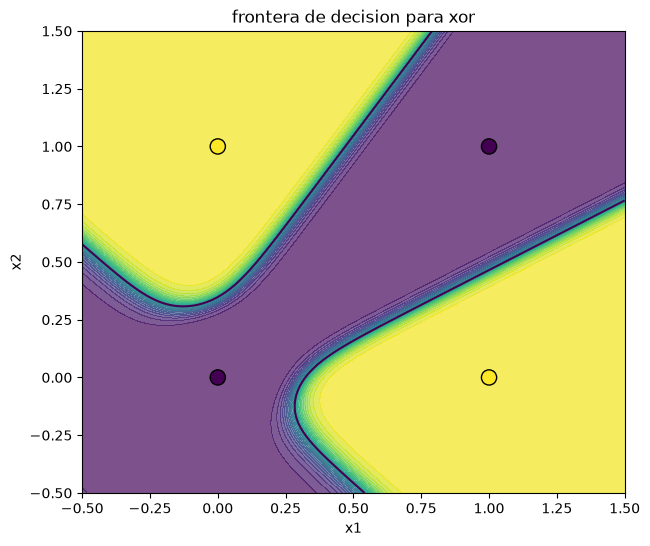

In [3]:
#creamos valores para ambos ejes
x1 = torch.linspace(-0.5, 1.5, 200)
x2 = torch.linspace(-0.5, 1.5, 200)

#creamos una malla sobre el plano
xx1, xx2 = torch.meshgrid(
    x1,
    x2,
    indexing="xy"
)

#convertimos la malla en pares
grid = torch.stack(
    [
        xx1.reshape(-1),
        xx2.reshape(-1)
    ],
    dim=1
)

#calculamos probabilidades sobre toda la malla
with torch.no_grad():

    grid_logits = model(grid)

    grid_probabilities = torch.sigmoid(
        grid_logits
    )

#recuperamos la forma original
zz = grid_probabilities.reshape(
    xx1.shape
)

#graficamos la frontera aprendida
plt.figure(figsize=(7, 6))

plt.contourf(
    xx1.numpy(),
    xx2.numpy(),
    zz.numpy(),
    levels=30,
    alpha=0.7
)

#marcamos la frontera de decision
plt.contour(
    xx1.numpy(),
    xx2.numpy(),
    zz.numpy(),
    levels=[0.5]
)

#graficamos los puntos xor
plt.scatter(
    x[:, 0].numpy(),
    x[:, 1].numpy(),
    c=y.squeeze().numpy(),
    s=120,
    edgecolors="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("frontera de decision para xor")

plt.show()

In [4]:
#definimos el modelo sin activacion
class MLPLineal(nn.Module):
    def __init__(self):
        super().__init__()

        #primera capa lineal
        self.fc1 = nn.Linear(2, 4)

        #segunda capa lineal
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x


#creamos el modelo lineal
model_lineal = MLPLineal()

#definimos perdida y optimizador
criterion_lineal = nn.BCEWithLogitsLoss()

optimizer_lineal = torch.optim.Adam(
    model_lineal.parameters(),
    lr=0.05
)

#entrenamos bajo las mismas condiciones
for epoch in range(2000):

    optimizer_lineal.zero_grad()

    logits = model_lineal(x)

    loss = criterion_lineal(
        logits,
        y
    )

    loss.backward()

    optimizer_lineal.step()


#evaluamos el modelo lineal
with torch.no_grad():

    logits = model_lineal(x)

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= 0.5
    ).float()

    accuracy = (
        predictions == y
    ).float().mean()


print("probabilidades:")
print(probabilities)

print("\npredicciones:")
print(predictions)

print(
    "\nexactitud:",
    accuracy.item() * 100,
    "%"
)

probabilidades:
tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000]])

predicciones:
tensor([[1.],
        [1.],
        [1.],
        [1.]])

exactitud: 50.0 %


Sin activacion las capas forman una transformacion afin, por eso mantienen una frontera de decision lineal. XOR necesita una frontera de decision no lineal.

In [5]:
#definimos la red solicitada
class RedMulticapa(nn.Module):
    def __init__(self):
        super().__init__()

        #primera capa oculta
        self.fc1 = nn.Linear(3, 4)

        #segunda capa oculta
        self.fc2 = nn.Linear(4, 4)

        #capa de salida
        self.fc3 = nn.Linear(4, 2)

        #activacion para capas ocultas
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x


#creamos la red
red = RedMulticapa()

#contamos todos los parametros
total_parametros = sum(
    parametro.numel()
    for parametro in red.parameters()
)

print(red)

print(
    "\ntotal de parametros:",
    total_parametros
)

RedMulticapa(
  (fc1): Linear(in_features=3, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

total de parametros: 46


In [6]:
#recorremos todos los parametros del modelo
for nombre, parametro in red.named_parameters():

    print(
        nombre,
        "->",
        tuple(parametro.shape)
    )

fc1.weight -> (4, 3)
fc1.bias -> (4,)
fc2.weight -> (4, 4)
fc2.bias -> (4,)
fc3.weight -> (2, 4)
fc3.bias -> (2,)
